In [26]:
import cv2
import numpy as np

#read img
img = cv2.imread("./lena.bmp",cv2.IMREAD_GRAYSCALE)

In [27]:
def binarize(img):
    b = img.copy()
    for i in range(b.shape[0]):
        for j in range(b.shape[1]):
            if b[i,j] >= 128:
                b[i,j] = 255
            else:
                b[i,j] = 0
    return b
binarized_img = binarize(img)
cv2.imwrite('./output/binarized.png',binarized_img)

True

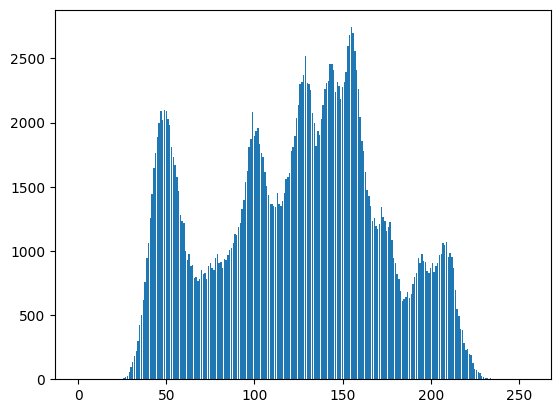

In [28]:
import matplotlib.pyplot as plt

def histogram(img):
    his = np.zeros(256)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            his[img[i,j]] += 1
    return his
his = histogram(img)
plt.bar(np.arange(his.shape[0]), his)
plt.savefig('./output/histogram.png')

In [132]:
import numpy as np
import cv2

def find(parent, i):
    if i not in parent:
        return i
    if parent[i] != i:
        parent[i] = find(parent, parent[i])
    return parent[i]

def union(parent, rank, x, y):
    xroot = find(parent, x)
    yroot = find(parent, y)
    
    if xroot != yroot:
        if xroot not in rank:
            rank[xroot] = 0
        if yroot not in rank:
            rank[yroot] = 0
        
        if rank[xroot] < rank[yroot]:
            parent[xroot] = yroot
        elif rank[xroot] > rank[yroot]:
            parent[yroot] = xroot
        else:
            parent[yroot] = xroot
            rank[xroot] += 1

def unique(arr):
    unique_set = set()
    for value in arr.flat:  # Iterate over flattened array
        if value != 0:  # Exclude background
            unique_set.add(value)
    return sorted(list(unique_set))

def scan(img):
    height, width = img.shape
    labels = np.zeros((height, width), dtype=np.int32)
    next_label = 1
    parent = {}
    rank = {}

    # First pass: assign preliminary labels
    for y in range(height):
        for x in range(width):
            if img[y, x] == 0:  # Skip background pixels
                continue

            neighbors = []
            if y > 0 and labels[y-1, x] != 0:
                neighbors.append(labels[y-1, x])
            if x > 0 and labels[y, x-1] != 0:
                neighbors.append(labels[y, x-1])

            if not neighbors:
                labels[y, x] = next_label
                parent[next_label] = next_label
                rank[next_label] = 0
                next_label += 1
            else:
                min_label = min(neighbors)
                labels[y, x] = min_label
                for neighbor_label in neighbors:
                    if neighbor_label != min_label:
                        union(parent, rank, min_label, neighbor_label)

    # Second pass: replace labels with root labels
    for y in range(height):
        for x in range(width):
            if labels[y, x] != 0:
                labels[y, x] = find(parent, labels[y, x])

    return labels

def two_pass(img, colors):
    labels = scan(img)
    out_img = cv2.cvtColor(img[:], cv2.COLOR_GRAY2BGR)
    
    # Use our custom unique function
    for key in unique(labels):

        if len(labels[labels == key]) < 500:
            labels[labels == key] = 0
    unique_labels = unique(labels)
    
    
    # Relabel components from 1 to n
    relabel_dict = {old_label: new_label for new_label, old_label in enumerate(unique_labels, start=1)}
    
    for y in range(labels.shape[0]):
        for x in range(labels.shape[1]):
            if labels[y, x] != 0:
                labels[y, x] = relabel_dict[labels[y, x]]
    
    
    # Create colored output image
    colors = np.array(colors)
    color_img = colors[labels]
    # print(color_img == [0,0,0])
    color_img[color_img == 0] = out_img[ color_img == 0]
    
    return color_img, labels

def find_mean_and_box(labels):
    info = {}
    for l in unique(labels):
        if l == 0:
            continue
        coord = []
        for i in range(labels.shape[0]):
            for j in range(labels.shape[1]):
                if labels[i,j] == l:
                    coord.append([i,j])
        coord = np.array(coord)
        m = [int(np.mean(coord[:,1])),int(np.mean(coord[:,0]))]
        x_min, y_min = min(coord[:,1]), min(coord[:,0])
        x_max, y_max = max(coord[:,1]), max(coord[:,0])
        info[l] = [m, (x_min, y_min), (x_max,y_max)]
    
    return info


# Assuming binarized_img is already defined
colors = [[0, 0, 0], [255, 255, 1], [1, 255, 120], [255, 120, 1], [255, 175, 230], [1, 120, 255]]
four_cc_img, labels = two_pass(binarized_img, colors)
info = find_mean_and_box(labels)
four_cc_img = four_cc_img.astype(np.uint8)
for k, l in info.items():
    cv2.line(four_cc_img, (l[0][0] - 7, l[0][1]), (l[0][0] + 7, l[0][1]), [0, 0, 255], 2)
    cv2.line(four_cc_img, (l[0][0], l[0][1] - 7), (l[0][0], l[0][1] + 7), [0, 0, 255], 2)
    cv2.rectangle(four_cc_img, l[1],l[2], [colors[k][0]-100, colors[k][1]-100, colors[k][2]-100], 2)

cv2.imwrite('./output/four_cc.png', four_cc_img)

True